In [32]:
!git clone https://github.com/just-abir/K-Means_AI_ML.git

fatal: destination path 'K-Means_AI_ML' already exists and is not an empty directory.


**STEP 1: Import Library & Dataset**

In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import joblib

mall_url="https://raw.githubusercontent.com/just-abir/AI_ML_Lab_Task/refs/heads/main/Lab_Task_AI_ML/K_Means/Dataset/Mall_Customers.csv"
df = pd.read_csv('/content/K-Means_AI_ML/K_Means/Dataset/Mall_Customers.csv')

print(df.head())
print(df.shape)
print(df.info())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [34]:
# 2. Select features for clustering
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

print(X.describe())

# 3. Scale the data (CRITICAL — K-Means uses Euclidean distance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n\n Scaled data sample:")
print(X_scaled[:5])

              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.000000               73.000000
max     70.000000          137.000000               99.000000


 Scaled data sample:
[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]


**Step 3: Find optimal K (Elbow Method) + Train the model**

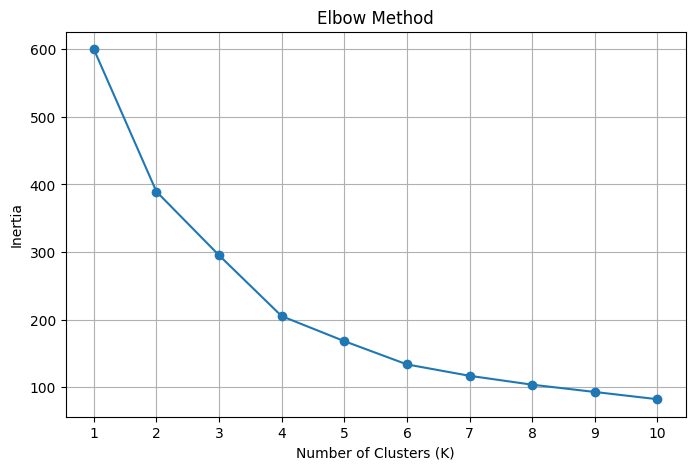

In [35]:
# 1. Elbow Method - find optimal number of clusters
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [36]:
# 2. Train final model with chosen K (commonly K=5 for Mall Customers, but check your elbow plot)
optimal_k = 5  # adjust based on your elbow plot

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = kmeans.labels_

print(df.head())
print(df['Cluster'].value_counts())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        1  
1        1  
2        0  
3        1  
4        1  
Cluster
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64


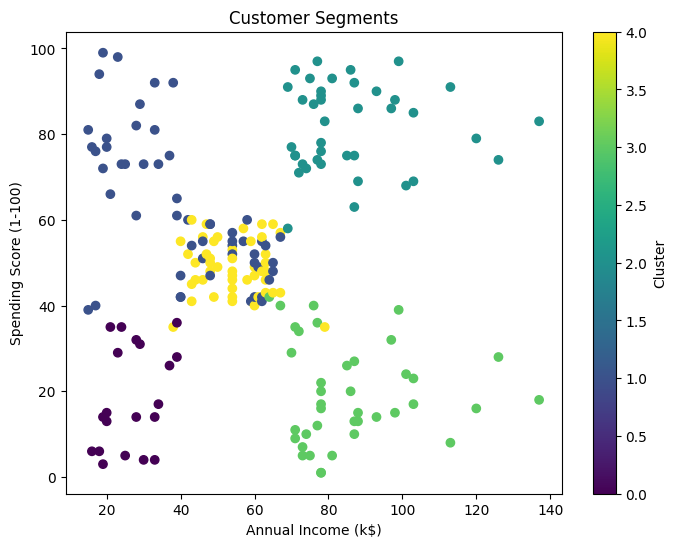

In [37]:
# 3. Visualize clusters (using Annual Income vs Spending Score)
plt.figure(figsize=(8,6))
scatter = plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                       c=df['Cluster'], cmap='viridis')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments')
plt.colorbar(scatter, label='Cluster')
plt.show()

**Step 4: Save the model + Test with your custom survey data**

In [38]:
# 1. Save the trained model and scaler
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved!")

Model and scaler saved!


In [39]:
# 2. Load your custom survey data from GitHub

custom_url="https://raw.githubusercontent.com/just-abir/AI_ML_Lab_Task/refs/heads/main/Lab_Task_AI_ML/K_Means/Dataset/custom_survey_data.csv"
custom_df = pd.read_csv('/content/K-Means_AI_ML/K_Means/Dataset/custom_survey_data.csv')

print(custom_df)

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   23                  28                      72
1           2  Female   31                  45                      55
2           3    Male   45                  80                      30
3           4  Female   27                  35                      68
4           5    Male   52                  95                      22
5           6  Female   19                  18                      85
6           7    Male   38                  62                      48
7           8  Female   60                 110                      15
8           9    Male   29                  50                      75
9          10  Female   41                  70                      40


In [40]:
# 3. Preprocess custom data EXACTLY like training data (use SAME scaler, don't refit)
X_custom = custom_df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X_custom_scaled = scaler.transform(X_custom)  # transform, NOT fit_transform

print(X_custom_scaled)

[[-1.13750203 -1.24279661  0.84631002]
 [-0.56336851 -0.59391632  0.18634349]
 [ 0.44136514  0.7420137  -0.78419553]
 [-0.85043527 -0.97561061  0.69102378]
 [ 0.94373197  1.31455514 -1.09476801]
 [-1.42456879 -1.62449091  1.35099031]
 [-0.06100169  0.05496398 -0.08540743]
 [ 1.51786549  1.88709658 -1.36651894]
 [-0.70690189 -0.40306917  0.96277471]
 [ 0.15429838  0.36031941 -0.39597992]]


In [41]:
# 4. Predict clusters for your custom data
custom_clusters = kmeans.predict(X_custom_scaled)
custom_df['Predicted_Cluster'] = custom_clusters

print(custom_df)

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   23                  28                      72   
1           2  Female   31                  45                      55   
2           3    Male   45                  80                      30   
3           4  Female   27                  35                      68   
4           5    Male   52                  95                      22   
5           6  Female   19                  18                      85   
6           7    Male   38                  62                      48   
7           8  Female   60                 110                      15   
8           9    Male   29                  50                      75   
9          10  Female   41                  70                      40   

   Predicted_Cluster  
0                  1  
1                  1  
2                  3  
3                  1  
4                  3  
5                  1  
6                  4  
7

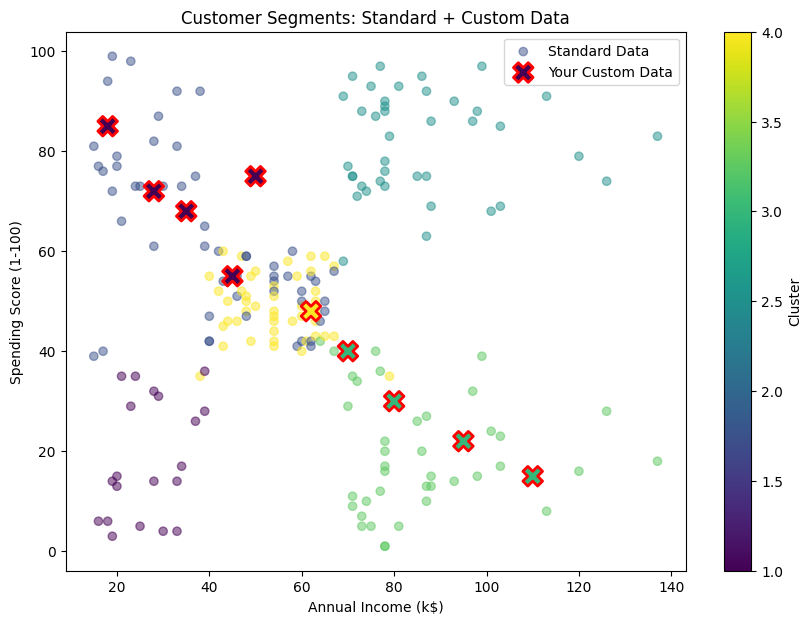

In [42]:
# 5. Visualize: standard data + custom data together
plt.figure(figsize=(10,7))

# Standard dataset points (colored by cluster)
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=df['Cluster'], cmap='viridis', alpha=0.5, label='Standard Data')

# Custom data points (highlighted with different marker)
plt.scatter(custom_df['Annual Income (k$)'], custom_df['Spending Score (1-100)'],
            c=custom_df['Predicted_Cluster'], cmap='viridis',
            marker='X', s=200, edgecolors='red', linewidths=2, label='Your Custom Data')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments: Standard Data vs Custom Survey Data')
plt.colorbar(label='Cluster')
plt.legend()
plt.title('Customer Segments: Standard + Custom Data')
plt.show()